# Clustering jerárquico aglomerativo y dendrograma
## Notebook guiado

En este notebook vamos a trabajar el **clustering jerárquico aglomerativo** usando el dataset **Iris**.  
El objetivo es entender:

- qué hace este algoritmo,
- cómo se ajusta con `AgglomerativeClustering`,
- cómo se construye un **dendrograma**,
- y cómo interpretar visualmente los agrupamientos.

---

## 1. Importación de librerías

En esta primera celda importamos las librerías necesarias:

- `numpy` para trabajar con arrays,
- `matplotlib` para representar gráficos,
- `dendrogram` desde `scipy` para dibujar el dendrograma,
- `AgglomerativeClustering` desde `sklearn` para aplicar el algoritmo,
- `load_iris` para cargar un dataset clásico de ejemplo.

Ejecuta la celda y comprueba que no aparecen errores.

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.cluster.hierarchy import dendrogram

from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import load_iris

## 2. Carga del dataset

Vamos a utilizar el dataset **Iris**, muy habitual en aprendizaje automático.

Este conjunto de datos contiene medidas de flores y suele utilizarse para comprobar si los algoritmos son capaces de encontrar grupos con características parecidas.

En este notebook trabajaremos con:

- `X`: las variables numéricas del dataset,
- `iris.feature_names`: el nombre de las variables,
- `iris.target_names`: las especies reales, que aquí solo usaremos como referencia final.

In [2]:
iris = load_iris()
X = iris.data

print("Forma del dataset:", X.shape)
print("Variables:", iris.feature_names)
print("Clases reales:", iris.target_names)

Forma del dataset: (150, 4)
Variables: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Clases reales: ['setosa' 'versicolor' 'virginica']


## 3. Primer vistazo a los datos

Antes de aplicar cualquier algoritmo, conviene observar:

- cuántas filas y columnas tiene el dataset,
- qué aspecto tienen los primeros registros,
- y qué representan sus variables.

Fíjate en que en este ejemplo estamos usando un algoritmo **no supervisado**: el modelo no necesita la clase real para agrupar.

In [3]:
print("Primeras 5 filas del dataset:")
print(X[:5])

Primeras 5 filas del dataset:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


## 4. ¿Qué hace el clustering jerárquico aglomerativo?

Este algoritmo sigue una idea muy simple:

1. Al principio, **cada dato forma su propio grupo**.
2. Después, el algoritmo va **uniendo los grupos más próximos**.
3. Este proceso continúa hasta formar una estructura jerárquica completa.

El resultado puede representarse mediante un **dendrograma**, que muestra en qué orden se fusionan los grupos y a qué distancia lo hacen.

## 5. Función auxiliar para dibujar el dendrograma

`AgglomerativeClustering` no dibuja directamente el dendrograma.  
Por eso usamos una función auxiliar que:

- toma el modelo ya entrenado,
- reconstruye la matriz de enlaces,
- y la pasa a `dendrogram()` para representarla.

No es necesario memorizar todos los detalles de la función, pero sí entender **para qué sirve**.

In [4]:
def plot_dendrogram(model, **kwargs):
    # Crear la matriz de enlaces necesaria para construir el dendrograma

    # Contar cuántas muestras hay debajo de cada nodo
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)

    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # nodo hoja
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    # Construir la matriz de linkage
    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Dibujar el dendrograma
    dendrogram(linkage_matrix, **kwargs)

## 6. Entrenamiento del modelo

Ahora ajustamos el modelo de clustering jerárquico.

### Observa este detalle importante:
Usamos:

- `distance_threshold=0`
- `n_clusters=None`

Esto se hace para que el algoritmo **construya el árbol completo** y así podamos representar después el dendrograma completo.

In [5]:
model = AgglomerativeClustering(distance_threshold=0, n_clusters=None)
model = model.fit(X)

print("Número de etiquetas asignadas:", len(model.labels_))
print("Primeras 10 etiquetas:", model.labels_[:10])

Número de etiquetas asignadas: 150
Primeras 10 etiquetas: [147 131 115 136 143  85  92 148 137 146]


## 7. Representación del dendrograma

Vamos a dibujar el dendrograma.

En este ejemplo usamos:

- `truncate_mode="level"` para no mostrar absolutamente todos los niveles,
- `p=3` para quedarnos con los niveles superiores y que el gráfico sea más fácil de interpretar.

Después puedes cambiar ese valor y observar qué ocurre.

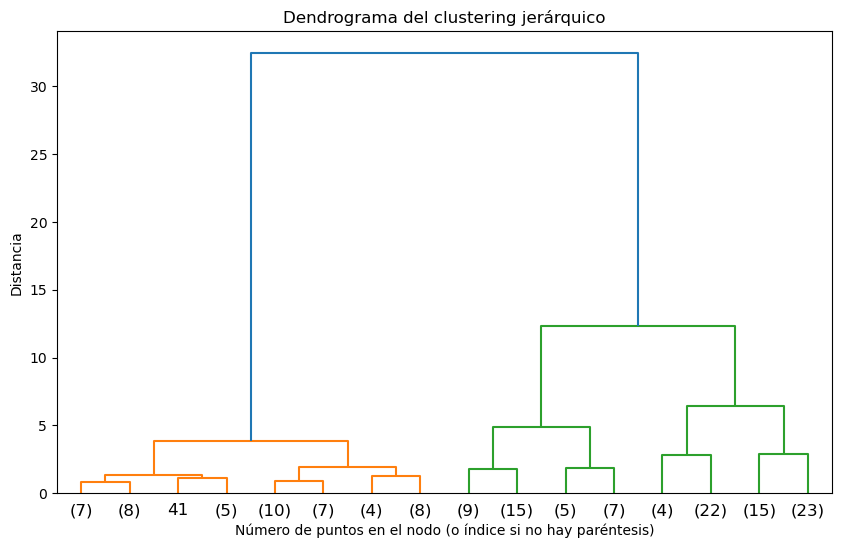

In [6]:
plt.figure(figsize=(10, 6))
plt.title("Dendrograma del clustering jerárquico")
plot_dendrogram(model, truncate_mode="level", p=3)
plt.xlabel("Número de puntos en el nodo (o índice si no hay paréntesis)")
plt.ylabel("Distancia")
plt.show()

## 8. Interpretación del dendrograma

Al observar el dendrograma, debes fijarte sobre todo en:

- **la altura** a la que se unen los grupos,
- y **los saltos grandes de distancia**.

### Idea clave
Si dos grupos se unen a poca altura, significa que son bastante parecidos.  
Si se unen a mucha altura, significa que son más diferentes.

Un posible criterio para decidir cuántos grupos tomar sería hacer un **corte horizontal** en una zona donde haya una separación clara.

## 9. Modificación de Valores

Prueba ahora alguna de estas modificaciones y observa cómo cambia el resultado:

1. Cambia `p=3` por `p=4` o `p=5`.
2. Elimina `truncate_mode="level"` para ver más detalle.
3. Investiga otros parámetros del modelo, como el criterio de enlace, si tu versión de `sklearn` lo permite.
4. Compara después este enfoque con **K-Means**.

Estas pruebas te ayudarán a entender que el clustering no da una única respuesta “correcta”, sino que depende de cómo representemos e interpretemos los datos.

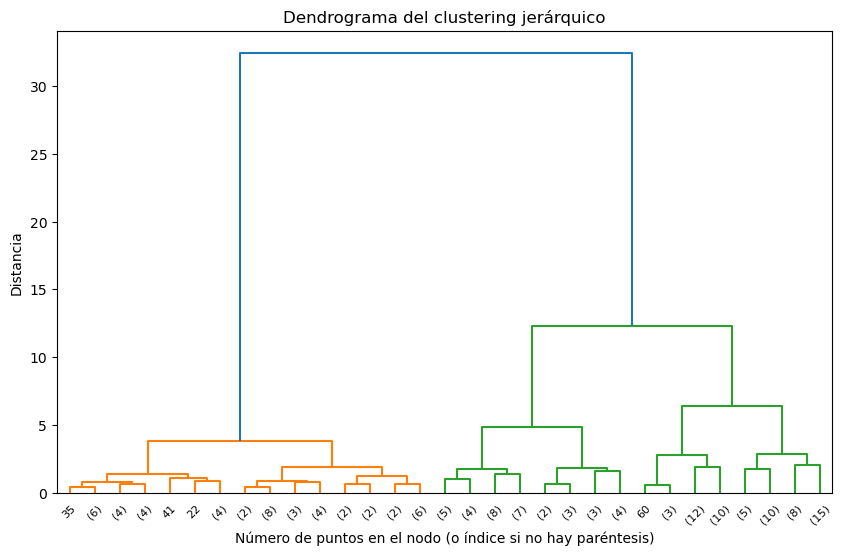

In [7]:
plt.figure(figsize=(10, 6))
plt.title("Dendrograma del clustering jerárquico")
plot_dendrogram(model, truncate_mode="level", p=4)
plt.xlabel("Número de puntos en el nodo (o índice si no hay paréntesis)")
plt.ylabel("Distancia")
plt.show()

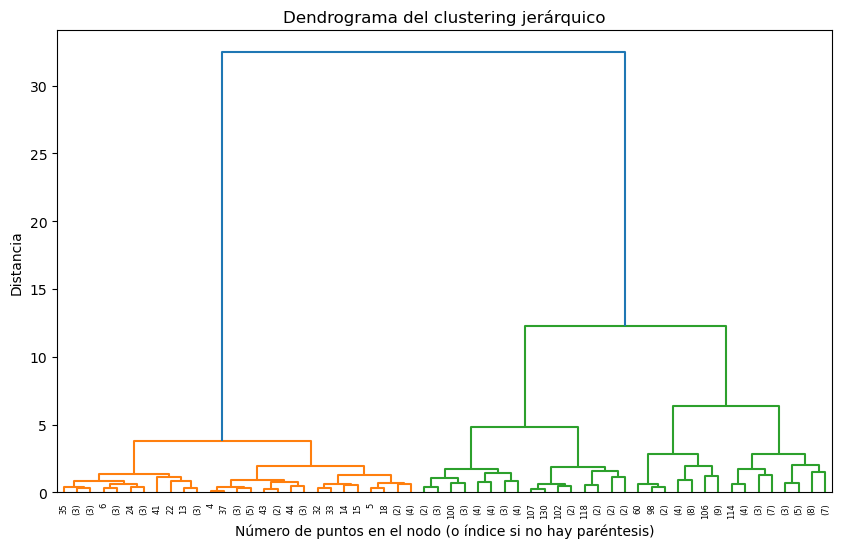

In [8]:
plt.figure(figsize=(10, 6))
plt.title("Dendrograma del clustering jerárquico")
plot_dendrogram(model, truncate_mode="level", p=5)
plt.xlabel("Número de puntos en el nodo (o índice si no hay paréntesis)")
plt.ylabel("Distancia")
plt.show()

## 10. Cuestiones

Responde brevemente:

1. ¿Por qué este algoritmo se considera de aprendizaje no supervisado?
- Se considera de aprendizaje no supervisado ya que el algoritmo agrupa sin etiquetado previo, en ningun momento al algoritmo se le ha indicado cuantos y que grupos hay.
- Es decir no hay una variable objetivo, ni una respuesta correcta previa.
2. ¿Qué representa la altura en el dendrograma?
- Representa la distancia que hay entre los diferentes clusteres. Cuanto mayor es la altura de la unión, mas diferentes son los grupos que se están combinando.
3. ¿Qué ventaja tiene el dendrograma frente a un método como K-Means?
- No necesita un numero de clusteres inicial y permite visualizar la estructura de los datos de manera jerarquica.
- Otra ventaja es que te permite tomar la decisión del numero de clusteres después de ver como se agrupan los datos, no antes (como en K-Means).
4. ¿Qué ocurriría si el dataset fuera muy grande?
- Visualmente se vería peor, ya que posiblemente crearía mas clusteres y llegaría un punto en el que no se visualizarían bien los datos.
- Además a nivel computacional, empeoraría y perdería el sentido, ya que K-Means tiene menor coste computacional.
5. ¿Crees que este método sirve más para explorar datos o para predecir? Razona tu respuesta.
- Es un metodo para explorar datos, ya que identifica patrones, comportamientos que hace que se creen agrupaciones, lo que nos servería para poder orientarnos mejor y - saber que hacer con los datos.
- No es un modelo de predicción ya que a un modelo predictivo le das un dato nuevo y te dice que es, en este caso, en el jerarquico si llega un dato nuevo, no te dice que es, se tendría que ejecutar casi todo el arbol jerarquico para ver donde encaja.

## 11. Conclusión

En este notebook has visto cómo:

- cargar un dataset clásico,
- aplicar clustering jerárquico aglomerativo,
- construir un dendrograma,
- e interpretar visualmente la formación de grupos.

Este tipo de técnica es especialmente útil en **análisis exploratorio**, cuando queremos descubrir estructura en los datos sin conocer previamente el número exacto de grupos.